# Initial Imports and Constants

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import math
import pickle

In [117]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [118]:
### switch to mask out transits
mask_transits = True
bootstrap = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [119]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [120]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC')
print(search_result)


SearchResult containing 47 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
...            ...  ...    ...     ...         ...      ...
 37 TESS Sector 86 2024   SPOC      20   269701147      0.0
 38 TESS Sector 78 2024   SPOC     120   269701147      0.0
 39 TESS Sector 76 2024   SPOC     120   269701147      0

In [121]:
# Use the `.table` attribute to filter and access data
table = search_result.table

# Get missions (sectors) that have 20-second exposures
sectors_with_20s = set(table[table['exptime'] == 20]['mission'])

print(sectors_with_20s)

{'TESS Sector 55', 'TESS Sector 48', 'TESS Sector 78', 'TESS Sector 60', 'TESS Sector 49', 'TESS Sector 83', 'TESS Sector 85', 'TESS Sector 56', 'TESS Sector 79', 'TESS Sector 82', 'TESS Sector 77', 'TESS Sector 75', 'TESS Sector 73', 'TESS Sector 51', 'TESS Sector 41', 'TESS Sector 59', 'TESS Sector 52', 'TESS Sector 76', 'TESS Sector 86'}


In [122]:
# Now build filtered list, preferring 20s over 120s
filtered_results = []

for mission in set(table['mission']):
    if mission in sectors_with_20s:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 20)]
    else:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 120)]
    if len(result) > 0:
        filtered_results.append(result[0])
# print(filtered_results)

In [123]:
# Create final SearchResult
from lightkurve.search import SearchResult
from astropy.table import vstack
# Extract the table rows from each mini SearchResult
filtered_tables = [sr.table[0] for sr in filtered_results]

# Stack them into one Astropy Table
stacked_table = vstack(filtered_tables)

# Create final SearchResult
filtered_search = SearchResult(stacked_table)

# Download all matching light curves
lc_collection = filtered_search.download_all()


# lc_collection = search_result.download_all()
print(lc_collection)

LightCurveCollection of 28 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [124]:
from lightkurve import LightCurveCollection
import numpy as np


transit_times1_120 = [1715.38944376, 1733.15078837, 1742.0300416,  1759.78984595, 1768.67178277,
                      1786.43280369, 1795.31050246, 1804.19095166, 1813.07136515, 1821.95176484,
                      1830.83076354, 1839.71251761, 1875.2311819,  1892.99194378, 1901.87235482,
                      1910.75139352, 1919.6318458,  1964.03452717, 1972.91376407, 1981.79441236,
                      1990.67230238, 1999.55438592, 2008.43231724, 2425.79790193, 2434.67770012,
                      2443.55794308, 2612.27944255, 2621.15960192, 2630.0397667,  2647.79994506,
                      2656.67995136, 2701.08043055, 2710.00204277, 2718.84057706, 2727.72079863,
                      2736.60080582, 2798.76153233, 2807.64155056, 2816.52154351, 2825.40175094,
                      2834.28170348, 2843.16186077, 2852.04199989, 2914.20260399, 2923.08253678,
                      2931.96267424, 2940.84257321, 2949.72062379, 2958.60306042, 3296.04633103,
                      3340.44674742, 3349.32689343, 3358.20705504, 3367.08701766, 3375.9672193,
                      3384.84722147, 3393.72725802, 3402.60730882, 3420.36752782, 3438.12784854,
                      3447.00780649, 3455.88802332, 3464.76803693, 3473.64804938, 3535.80877194,
                      3544.68878001, 3553.56898689, 3562.44894255, 3571.32911764, 3580.20924966,
                      3615.72952053, 3633.48972638, 3642.37430564, 3660.12998926]
transit_times2_120 = [1726.07571219, 1754.65511506, 1783.23282912, 1811.81444057, 1840.39305961,
                      1897.55298087, 1926.13318022, 2440.5671511,  2612.04495659, 2640.62479627,
                      2697.78410709, 2726.36360003, 2812.10273058, 2840.68221763, 2926.42135249,
                      2955.05822891, 3297.95694203, 3355.11614071, 3383.69584474, 3440.8551862,
                      3469.43477825, 3555.1738697,  3583.75371223, 3612.33302674, 3640.91275712]
transit_times3_120 = [1743.60505174, 1781.95645021, 1820.30596336, 1897.00715535, 1973.70543708,
                      2433.90801186, 2625.65882173, 2664.00907691, 2702.35914648, 2740.70921642,
                      2817.40951948, 2932.45965505, 3354.31129592, 3392.66152132, 3469.29195181,
                      3546.0619494,  3584.34445526, 3622.76232735, 3661.1123786]


T14_1 = 2.939 * 0.0416667
T14_2 = 4.162 * 0.0416667
T14_3 = 5.36 * 0.0416667

if mask_transits == True:
    # Store detrended, masked individual light curves
    detrended_lcs = []

    for lc in lc_collection:
        lc_clean = lc.remove_nans()
        times = lc_clean.time.value
        mask = np.zeros_like(times, dtype=bool)

        # Apply transit time masks
        for transit_time in transit_times1_120:
            mask |= (times > (transit_time - (T14_1/2)*1.5)) & (times < (transit_time + (T14_1/2)*1.5))
        for transit_time in transit_times2_120:
            mask |= (times > (transit_time - (T14_2/2)*1.5)) & (times < (transit_time + (T14_2/2)*1.5))
        for transit_time in transit_times3_120:
            mask |= (times > (transit_time - (T14_3/2)*1.5)) & (times < (transit_time + (T14_3/2)*1.5))

        # Choose flattening window size based on cadence
        if lc.meta["EXPOSURE"] < 60:
            window = 1001
        else:
            window = 301

        window = 1901

        try:
            lc_flat = lc_clean.normalize().flatten(window_length=window, mask=mask).remove_outliers()
            detrended_lcs.append(lc_flat)
        except Exception as e:
            print(f"Skipping one LC due to error: {e}")

    # Stitch all masked/detrended LCs
    combined_lc = LightCurveCollection(detrended_lcs).stitch()

else:
    # Detrend individually without transit masking
    detrended_lcs = []

    for lc in lc_collection:
        lc_clean = lc.remove_nans()

        # Choose flattening window based on cadence
        if lc.meta["EXPOSURE"] < 60:
            window = 1001
        else:
            window = 301

        try:
            lc_flat = lc_clean.normalize().flatten(window_length=window).remove_outliers()
            detrended_lcs.append(lc_flat)
        except Exception as e:
            print(f"Skipping one LC due to error: {e}")

# Optional plot
# combined_lc.plot()
# plt.show()
# Stitch all flattened LCs
combined_lc = LightCurveCollection(detrended_lcs).stitch()


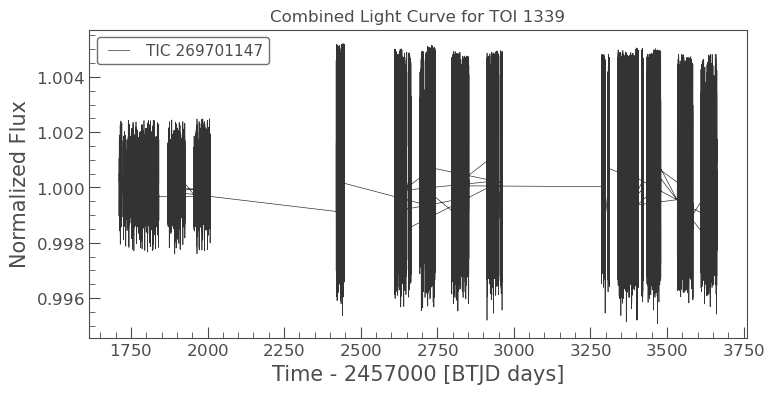

In [125]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [126]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1816.08521061 1816.08659947 1816.08798834 ... 3662.82669654 3662.82692802
 3662.8271595 ]
[1.00012291 0.99861597 0.99982321 ... 1.00121802 0.99805659 1.00088205]


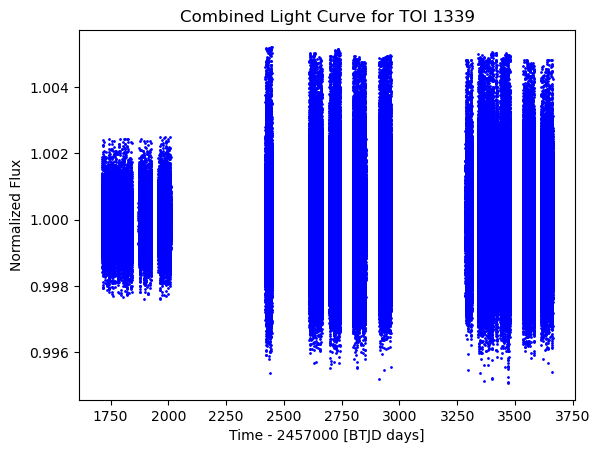

In [127]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS runs

## BLS 1

`period` contains 147250 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


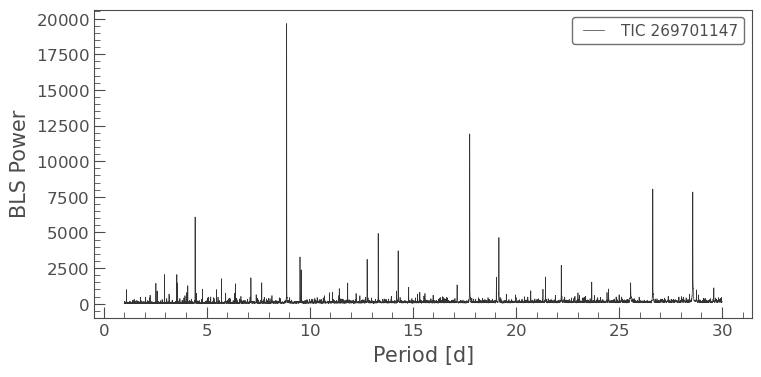

In [128]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 30, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [129]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 8.88009 days
Best candidate t0: 1715.39077 days
Best candidate dur: 0.10000 days


In [130]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*1.5)

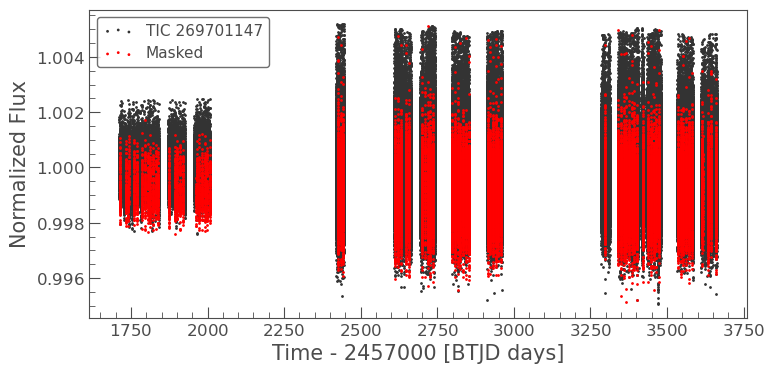

In [131]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [132]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


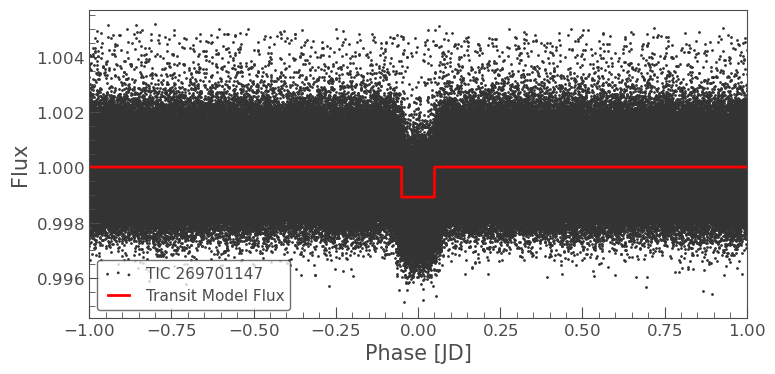

In [133]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


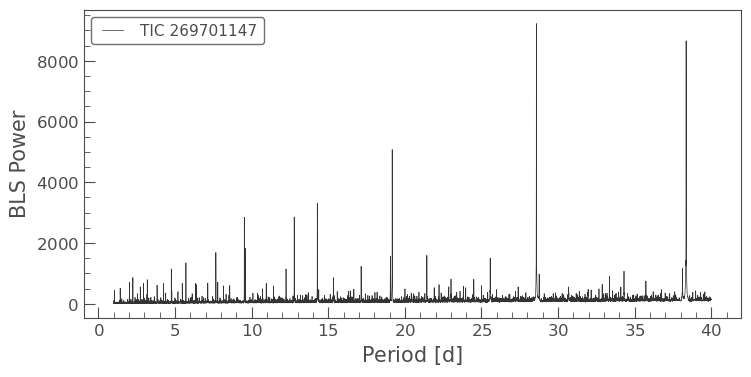

In [134]:
period = np.linspace(1, 40, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [135]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 28.57966 days
Best candidate t0 2: 1726.07077 days


In [136]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

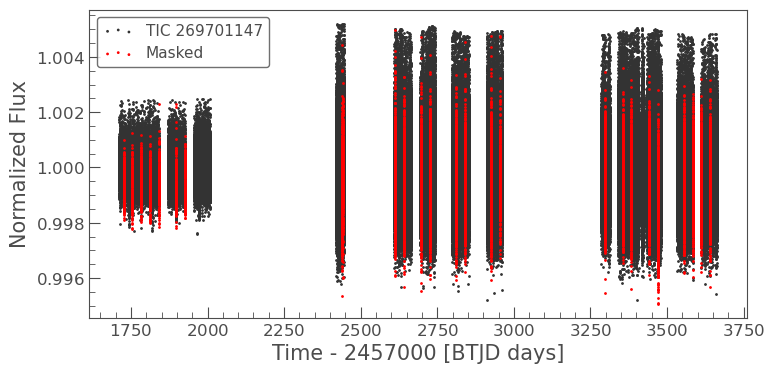

In [137]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [138]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

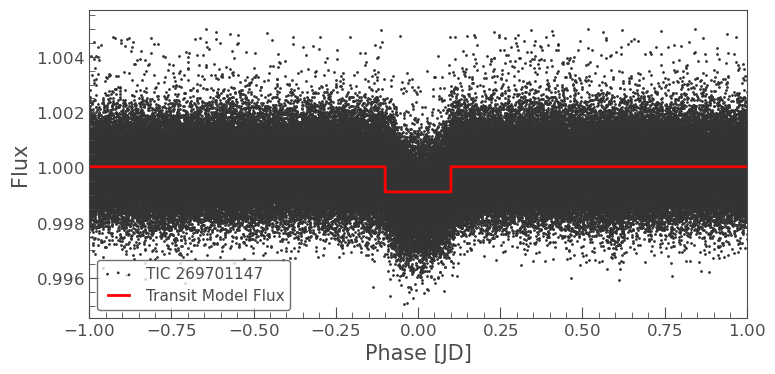

In [139]:
ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 3

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


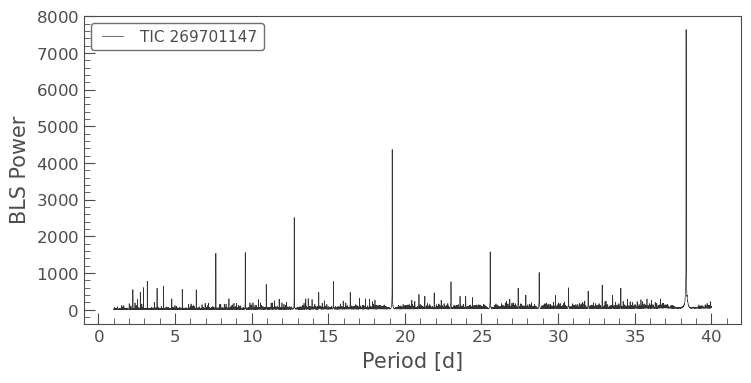

In [140]:
period = np.linspace(1, 40, 10000)
bls_3 = masked_lc_2.to_periodogram('bls', period=period, frequency_factor=500)
bls_3.plot()
plt.show()

In [141]:
planet_3_period = bls_3.period_at_max_power
planet_3_t0 = bls_3.transit_time_at_max_power
planet_3_dur = bls_3.duration_at_max_power

print(f"Best candidate period 3: {planet_3_period.value:.5f} days")
print(f"Best candidate t0 3: {planet_3_t0.value:.5f} days")

Best candidate period 3: 38.35014 days
Best candidate t0 3: 1743.60577 days


In [142]:
planet_3_mask = bls_3.get_transit_mask(period=planet_3_period,
                                     transit_time=planet_3_t0,
                                     duration=planet_3_dur*2.5)

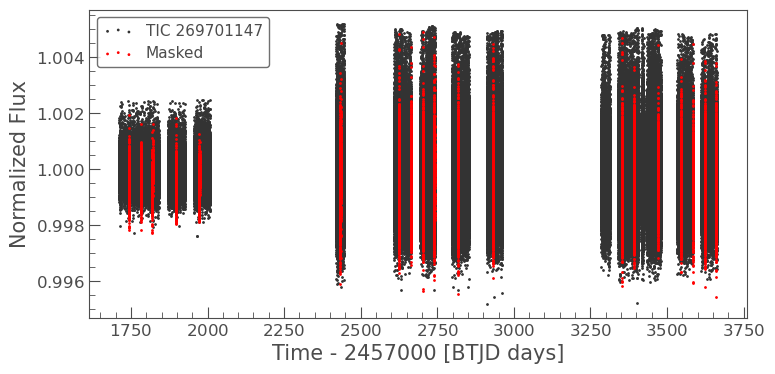

In [143]:
masked_lc_3 = masked_lc_2[~planet_3_mask]
ax = masked_lc_3.scatter();
masked_lc_2[planet_3_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [144]:
planet_3_model = bls_3.get_transit_model(period=planet_3_period,
                                       transit_time=planet_3_t0,
                                       duration=planet_3_dur)

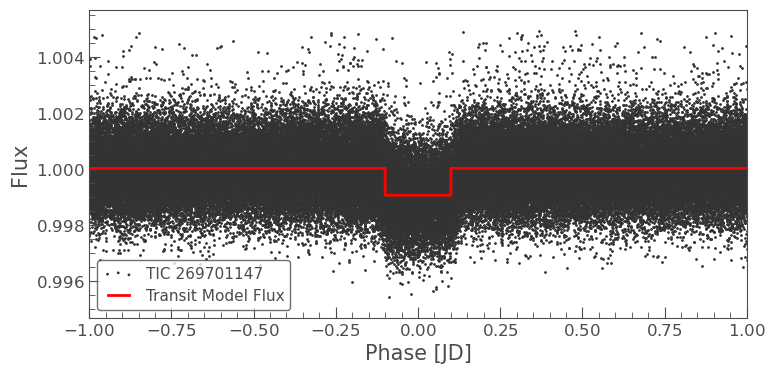

In [145]:
ax = masked_lc_2.fold(planet_3_period, planet_3_t0).scatter()
planet_3_model.fold(planet_3_period, planet_3_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

# Transit Models

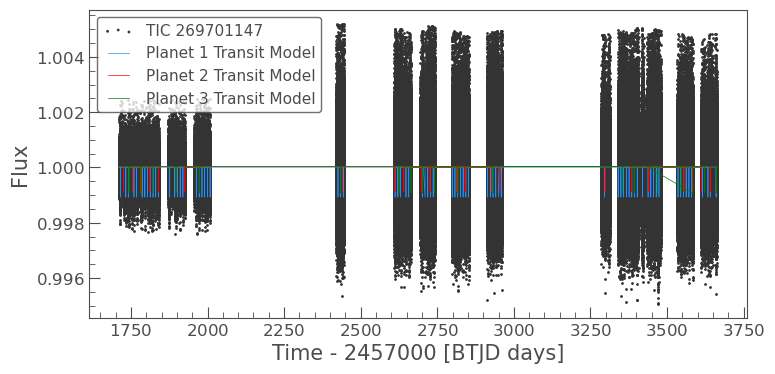

In [146]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

# Finding transit guess times based on models

In [147]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = np.sort(planet_1_model.time.value[peaks_1])
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1715.38944376 1733.15078837 1742.0300416  1759.78984595 1768.67178277
 1786.43280369 1795.31050246 1804.19095166 1813.07136515 1821.95176484
 1830.83076354 1839.71251761 1875.2311819  1892.99194378 1901.87235482
 1910.75139352 1919.6318458  1964.03452717 1972.91376407 1981.79441236
 1990.67230238 1999.55438592 2008.43231724 2425.79790193 2434.67770012
 2443.55794308 2612.27944255 2621.15960192 2630.0397667  2647.79994506
 2656.67995136 2701.08043055 2710.00204277 2718.84057706 2727.72079863
 2736.60080582 2798.76153233 2807.64155056 2816.52154351 2825.40175094
 2834.28170348 2843.16186077 2852.04199989 2914.20260399 2923.08253678
 2931.96267424 2940.84257321 2949.72062379 2958.60306042 3296.04633103
 3340.44674742 3349.32689343 3358.20705504 3367.08701766 3375.9672193
 3384.84722147 3393.72725802 3402.60730882 3420.36752782 3438.12784854
 3447.00780649 3455.88802332 3464.76803693 3473.64804938 3535.80877194
 3544.68878001 3553.56898689 3562.44894

In [148]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = np.sort(planet_2_model.time.value[peaks_2])
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1726.07015657 1754.64955949 1783.22866248 1811.8088851  1840.38750416
 1897.54742539 1926.1276247  2440.56205842 2612.04032706 2640.61970375
 2697.77901446 2726.35873884 2812.09763792 2840.67758798 2926.41626
 2955.06795092 3297.95184954 3355.11127969 3383.6907522  3440.85009356
 3469.42968557 3555.16877703 3583.74861961 3612.32816569 3640.90766462]


In [149]:
# Find all local minima (i.e., transit dips)
peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-5)
transit_times_3 = np.sort(planet_3_model.time.value[peaks_3])
fluxes_3 = planet_3_model.flux.value[peaks_3]

print("Planet 3 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_3)

Planet 3 transit dip times and depths:
[1743.60505174 1781.95645021 1820.30596336 1897.00715535 1973.70543708
 2433.90801186 2625.65882173 2664.00907691 2702.35914648 2740.70921642
 2817.40951948 2932.45965505 3354.31129592 3392.66152132 3469.27065516
 3546.0619494  3584.34445526 3622.76232735 3661.1123786 ]


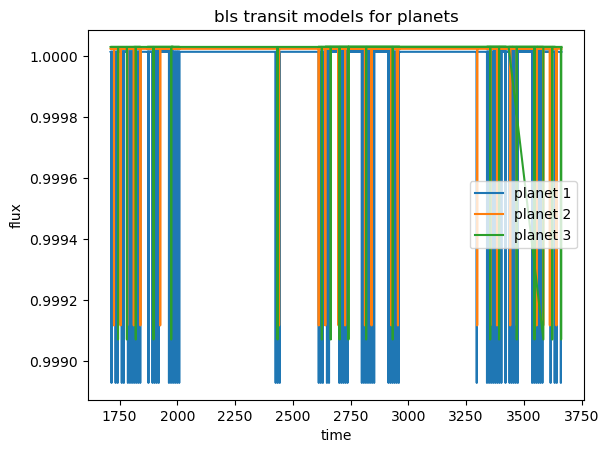

In [150]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')

plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Save data

In [151]:
# Store the variables in a dictionary
data = {
    'time': time,
    'flux': flux.unmasked,
    'flux_err': flux_err.unmasked,
    'transit_times_1': transit_times_1,
    'transit_times_2': transit_times_2,
    'transit_times_3': transit_times_3,
    'planet_1_period': planet_1_period.value,
    'planet_2_period': planet_2_period.value,
    'planet_3_period': planet_3_period.value,
    'planet_1_t0': planet_1_t0.value.unmasked,
    'planet_2_t0': planet_2_t0.value.unmasked,
    'planet_3_t0': planet_3_t0.value.unmasked
}
if bootstrap == True:
    # Save the data to a file
    file_path = 'toi_1339_bls_data.pkl'
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)

else:
    # Save the data to a file
    file_path = 'toi_1339_bls_data_no_bootstrap.pkl'
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)

print(f"Data saved to {file_path}")

Data saved to toi_1339_bls_data.pkl


In [152]:
print(data)

{'time': array([1816.08521061, 1816.08659947, 1816.08798834, ..., 3662.82669654,
       3662.82692802, 3662.8271595 ]), 'flux': array([1.00012291, 0.99861597, 0.99982321, ..., 1.00121802, 0.99805659,
       1.00088205]), 'flux_err': array([0.00045358, 0.00045335, 0.00045308, ..., 0.00090445, 0.00090321,
       0.00090457]), 'transit_times_1': array([1715.38944376, 1733.15078837, 1742.0300416 , 1759.78984595,
       1768.67178277, 1786.43280369, 1795.31050246, 1804.19095166,
       1813.07136515, 1821.95176484, 1830.83076354, 1839.71251761,
       1875.2311819 , 1892.99194378, 1901.87235482, 1910.75139352,
       1919.6318458 , 1964.03452717, 1972.91376407, 1981.79441236,
       1990.67230238, 1999.55438592, 2008.43231724, 2425.79790193,
       2434.67770012, 2443.55794308, 2612.27944255, 2621.15960192,
       2630.0397667 , 2647.79994506, 2656.67995136, 2701.08043055,
       2710.00204277, 2718.84057706, 2727.72079863, 2736.60080582,
       2798.76153233, 2807.64155056, 2816.52154351, 